# CartPole-v1 — Classical DQN

Train, inspect, and watch the classical baseline agent play. Solves CartPole-v1 (mean reward 500.0/500 over 100 evaluation episodes) in about a minute on CPU. For fast visualization purposes.

Run cells top to bottom. Re-running the training cell overwrites `results/classical_nb_*`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from cartpole_dqn import train
from watch import rollout, animate, load_policy_net

%matplotlib inline

## Train

Defaults are the RL-Zoo tuned CartPole-v1 config, plus reward shaping and Double DQN (both on by default for the classical agent — see `cartpole_dqn.py`'s `train()` docstring). ~80,000 environment steps, roughly a minute.

[classical_nb] episode    0  reward   14.0  avg(1)   14.0  loss  0.0000  eps 0.999
[classical_nb] episode   20  reward   18.0  avg(21)   22.6  loss  0.0000  eps 0.964
[classical_nb] episode   40  reward   11.0  avg(41)   24.6  loss  0.0000  eps 0.925
[classical_nb] episode   60  reward   13.0  avg(61)   24.8  loss  0.0000  eps 0.886
[classical_nb] episode   80  reward   30.0  avg(81)   27.8  loss  0.0000  eps 0.831
[classical_nb] episode  100  reward   74.0  avg(100)   28.6  loss  0.3863  eps 0.785
[classical_nb] episode  120  reward   27.0  avg(100)   31.6  loss  0.0000  eps 0.727
[classical_nb] episode  140  reward  114.0  avg(100)   34.5  loss  0.2249  eps 0.665
[classical_nb] episode  160  reward  150.0  avg(100)   45.1  loss  0.1492  eps 0.548
[classical_nb] episode  180  reward  500.0  avg(100)   85.8  loss  0.0784  eps 0.188
[classical_nb] episode  200  reward  500.0  avg(100)  179.6  loss  0.0532  eps 0.040
[classical_nb] episode  220  reward  500.0  avg(100)  271.9  loss  0.06

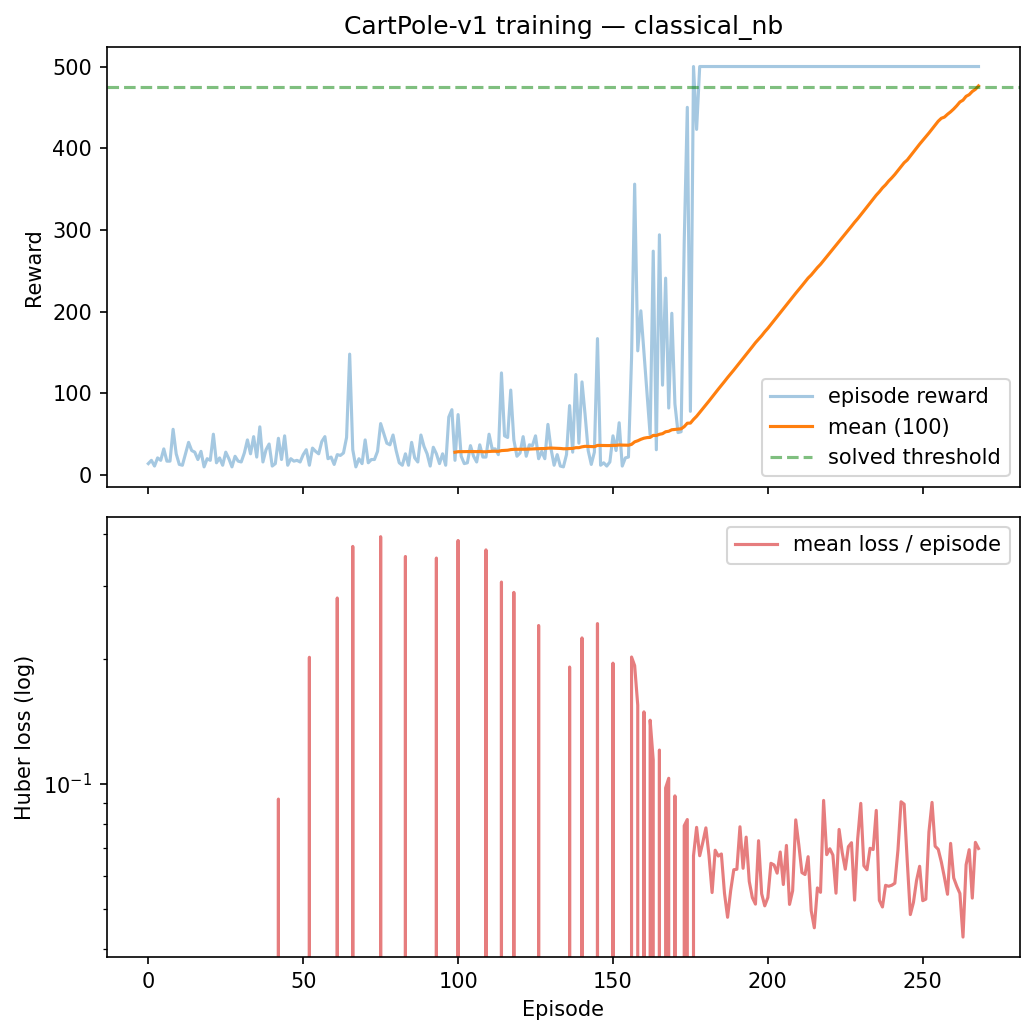

In [2]:
run = train(agent="classical", total_steps=80_000, seed=0, tag="_nb", out_dir="results")

## Results

In [3]:
print(f"solved            : {run['solved']}")
print(f"greedy eval mean  : {run['greedy_eval_mean']:.1f}  "
     f"(min {min(run['greedy_eval_rewards']):.0f}, max {max(run['greedy_eval_rewards']):.0f}, "
     f"{len(run['greedy_eval_rewards'])} episodes)")
print(f"parameters        : {run['params']}")
print(f"episodes trained  : {run['episodes_run']}")
print(f"wall clock        : {run['elapsed_sec']:.1f} s")

solved            : True
greedy eval mean  : 500.0  (min 500, max 500, 100 episodes)
parameters        : 67586
episodes trained  : 269
wall clock        : 117.8 s


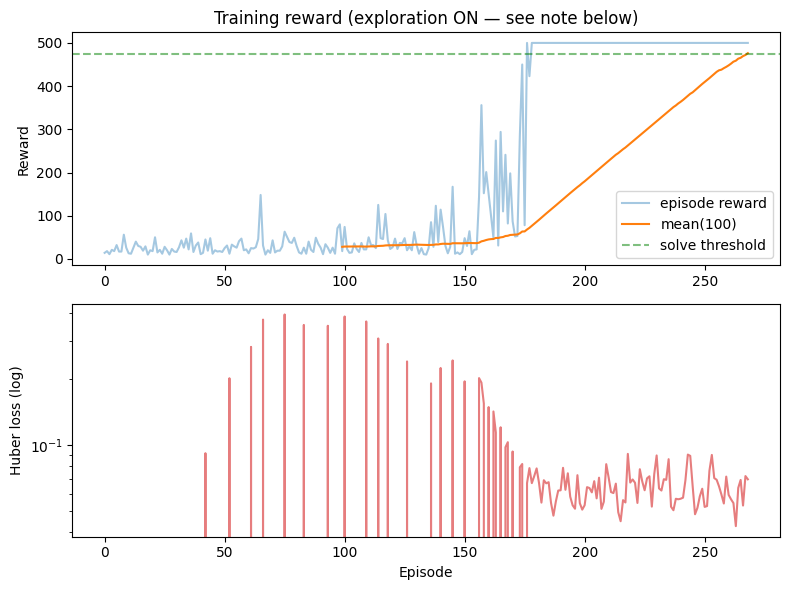

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(run["episode_rewards"], alpha=0.4, label="episode reward")
if len(run["episode_rewards"]) >= 100:
    means = np.convolve(run["episode_rewards"], np.ones(100) / 100, mode="valid")
    ax1.plot(range(99, len(run["episode_rewards"])), means, label="mean(100)")
ax1.axhline(475, color="green", ls="--", alpha=0.5, label="solve threshold")
ax1.set_ylabel("Reward")
ax1.set_title("Training reward (exploration ON — see note below)")
ax1.legend()

ax2.plot(run["episode_losses"], color="tab:red", alpha=0.6)
ax2.set_yscale("log")
ax2.set_ylabel("Huber loss (log)")
ax2.set_xlabel("Episode")

plt.tight_layout()
plt.show()

**Why the curve above looks noisy and doesn't stay above the threshold:** it's exploration-on training reward, and DQN oscillates — the policy repeatedly reaches a strong basin and then trains past it. The `solved` verdict and `greedy_eval_mean` printed above are measured on a single **frozen, best-found snapshot** (ε=0, evaluated fresh on held-out seeds after training), which is also what gets saved to `results/classical_nb_policy.pt` and animated below. The two numbers are not measuring the same thing — that's expected, not a bug.

## Watch it play

survived 500 steps (10.0s simulated)


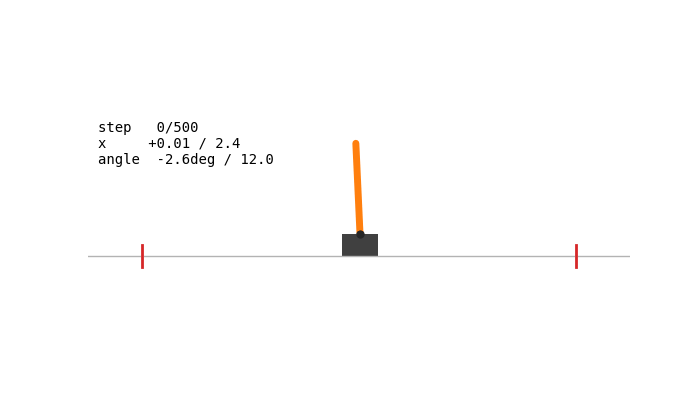

In [5]:
net = load_policy_net("results/classical_nb_policy.pt")
states = rollout(net, seed=0)
print(f"survived {len(states) - 1} steps ({(len(states) - 1) * 0.02:.1f}s simulated)")

animate(states, "results/classical_nb.gif", stride=2)
display(Image(filename="results/classical_nb.gif"))